# Title

 ### A Data-Driven Approach to Classifying Obesity Levels Using Supervised Machine Learning.

# Source - UCI Machine Learning Repository

https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

# Introduction & Dataset Description

**Introduction**

Obesity is a growing global health concern influenced by a combination of dietary habits, lifestyle behaviors, and physical conditions. Understanding these factors is essential for assessing obesity risk and designing effective interventions. This project uses the Estimation of Obesity Levels Based on Eating Habits and Physical Condition dataset from the UCI Machine Learning Repository to analyze how eating patterns and physical activity relate to different obesity categories. Using data-processing techniques, we aim to explore relationships among variables and prepare the dataset for predictive modeling.

**Dataset Description**

The dataset contains 2,111 records and 17 attributes, collected from individuals in Mexico, Peru, and Colombia. About 23% of the instances were gathered through a survey, while 77% were synthetically generated to balance class distribution. The dataset includes demographic information, eating habits, physical activity, and lifestyle factors. The target variable categorizes individuals into seven obesity levels, ranging from underweight to obesity type III. No missing values are reported.

| **Feature**                    | **Type**        | **Description**                           |
| ------------------------------ | --------------- | ----------------------------------------- |
| Gender                         | Categorical     | Male or Female                            |
| Age                            | Numerical       | Age in years                              |
| Height                         | Numerical       | Height in meters                          |
| Weight                         | Numerical       | Weight in kilograms                       |
| family_history_with_overweight | Categorical     | Whether close relatives are overweight    |
| FAVC                           | Categorical     | Frequent consumption of high-calorie food |
| FCVC                           | Numerical (1–3) | Frequency of vegetable consumption        |
| NCP                            | Numerical (1–4) | Number of main meals per day              |
| CAEC                           | Categorical     | Frequency of eating between meals         |
| SMOKE                          | Categorical     | Smoking status                            |
| CH2O                           | Numerical (1–3) | Daily water intake                        |
| SCC                            | Categorical     | Monitoring of daily calorie consumption   |
| FAF                            | Numerical (0–3) | Weekly physical activity frequency        |
| TUE                            | Numerical (0–2) | Daily time using electronic devices       |
| CALC                           | Categorical     | Alcohol consumption frequency             |
| MTRANS                         | Categorical     | Mode of transportation used               |
| **NObesity (Target)**          | Categorical     | 7-level obesity classification            |


In [1]:
# =========================================================
# Generic Imports
# =========================================================
import numpy as np                            # Numerical computations
import pandas as pd                           # Data handling
import matplotlib.pyplot as plt               # Plotting
import seaborn as sns                         # Statistical visualization
import warnings                               # Suppress warnings
warnings.filterwarnings("ignore")

# =========================================================
# Preprocessing & Transformers
# =========================================================
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer

# =========================================================
# Models
# =========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================================================
# Model Pipelines
# =========================================================
from sklearn.pipeline import Pipeline

# =========================================================
# Model Selection & Hyperparameter Tuning
# =========================================================
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

# =========================================================
# Evaluation Metrics
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Data Import & Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import zipfile
import io
import requests

# URL of the ZIP file on UCI
obesity_url = "https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"

# Download the ZIP file
response = requests.get(obesity_url)

# Open the ZIP
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Identify the CSV you want (there are multiple)
csv_filename = "ObesityDataSet_raw_and_data_sinthetic.csv"

# Load it
obesity_df = pd.read_csv(zip_file.open(csv_filename))

print("Obesity dataset loaded!")
print(obesity_df.head())
print(obesity_df.shape)


Obesity dataset loaded!
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Publi

In [3]:
# View the shape of the dataset
obesity_df.shape

(2111, 17)

In [4]:
# Elements in dataframe
obesity_df.size

35887

In [5]:
# Display the first 5 rows of the dataset
obesity_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
# Display the last 5 rows of the dataset
obesity_df.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [7]:
# Check for missing (NaN) values in each column
obesity_df.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [8]:
# Check for duplicate rows in the dataset
duplicate_count = obesity_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 24


In [9]:
# Remove duplicate rows to maintain data integrity and prevent redundancy
obesity_df = obesity_df.drop_duplicates()

# Verify that all duplicates have been removed successfully
print("Duplicate rows after removal:", obesity_df.duplicated().sum())

# Display the updated dataset shape (rows, columns) after cleaning
print("Shape after removal:", obesity_df.shape)

Duplicate rows after removal: 0
Shape after removal: (2087, 17)



## Renaming Columns for Better Understanding

| **Old Column Name**              | **New Column Name**           | **Description**                                       |
| -------------------------------- | ----------------------------- | ----------------------------------------------------- |
| `Gender`                         | **Gender**                    | Gender of the individual                              |
| `Age`                            | **Age**                       | Age (in years)                                        |
| `Height`                         | **Height**                    | Height (in meters)                                    |
| `Weight`                         | **Weight**                    | Weight (in kilograms)                                 |
| `Family_history_with_overweight` | **Family_History_Overweight** | Indicates family history of overweight/obesity        |
| `FAVC`                           | **HighCal_Food_Consumption**  | Frequency of consuming high-calorie foods             |
| `FCVC`                           | **Veg_Consumption_Freq**      | Frequency of vegetable consumption                    |
| `NCP`                            | **Num_Main_Meals**            | Number of main meals per day                          |
| `CAEC`                           | **Snacking_Habits**           | Consumption of food between meals (snacking tendency) |
| `SMOKE`                          | **Smoking_Habit**             | Smoking status (Yes/No)                               |
| `CH2O`                           | **Water_Intake**              | Daily water consumption                               |
| `SCC`                            | **Calorie_Monitoring**        | Whether the person monitors calorie intake            |
| `FAF`                            | **Physical_Activity_Freq**    | Frequency of physical activity or exercise            |
| `TUE`                            | **Tech_Usage_Time**           | Daily time spent using technological devices          |
| `CALC`                           | **Alcohol_Consumption**       | Frequency of alcohol consumption                      |
| `MTRANS`                         | **Transport_Mode**            | Mode of daily transportation                          |
| `NObeyesdad`                     | **Obesity_Level**             | Target variable representing obesity level            |


In [10]:
# Rename columns for better readability and understanding
obesity_df.rename(columns={
    'Gender': 'Gender',
    'Age': 'Age',
    'Height': 'Height',
    'Weight': 'Weight',
    'Family_history_with_overweight': 'Family_History_Overweight',
    'FAVC': 'HighCal_Food_Consumption',
    'FCVC': 'Veg_Consumption_Freq',
    'NCP': 'Num_Main_Meals',
    'CAEC': 'Snacking_Habits',
    'SMOKE': 'Smoking_Habit',
    'CH2O': 'Water_Intake',
    'SCC': 'Calorie_Monitoring',
    'FAF': 'Physical_Activity_Freq',
    'TUE': 'Tech_Usage_Time',
    'CALC': 'Alcohol_Consumption',
    'MTRANS': 'Transport_Mode',
    'NObeyesdad': 'Obesity_Level'
}, inplace=True)


In [11]:
# Verify column names and preview the first few records after renaming
obesity_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,HighCal_Food_Consumption,Veg_Consumption_Freq,Num_Main_Meals,Snacking_Habits,Smoking_Habit,Water_Intake,Calorie_Monitoring,Physical_Activity_Freq,Tech_Usage_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [12]:
# Generate an overview of dataset schema to inspect data types and completeness
obesity_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   object 
 5   HighCal_Food_Consumption        2087 non-null   object 
 6   Veg_Consumption_Freq            2087 non-null   float64
 7   Num_Main_Meals                  2087 non-null   float64
 8   Snacking_Habits                 2087 non-null   object 
 9   Smoking_Habit                   2087 non-null   object 
 10  Water_Intake                    2087 non-null   float64
 11  Calorie_Monitoring              2087 non-null   object 
 12  Physical_Activity_Freq          2087 no

## Numeric Feature Summary

In [13]:
# Select only continuous numerical features
numerical_cols = ["Age", "Height", "Weight"]

# Display statistical summary
obesity_df[numerical_cols].describe()

,Age,Height,Weight
count,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730
std,6.368801,0.093186,26.190847
min,14.000000,1.450000,39.000000
25%,19.915937,1.630178,66.000000
50%,22.847618,1.701584,83.101100
75%,26.000000,1.769491,108.015907
max,61.000000,1.980000,173.000000


 ### Key Observations
**Age**

- Mean age ≈ 24 years, with most individuals between 20–26.

- Values range from 14 to 61, all realistic.

- Slight right skew due to some older participants.

**Height**

- Average height ≈ 1.70 m, with normal human variation (SD ≈ 0.09 m).

- Range 1.45–1.98 m, all within typical limits.

- Distribution appears fairly symmetric.

**Weight**

- Mean weight ≈ 86.9 kg, higher due to presence of overweight/obesity cases.

- Large variability (SD ≈ 26 kg) with values from 39 to 173 kg.

- Right-skewed because of heavier individuals.

 ### Distribution and Boxplots of Continuous Variables

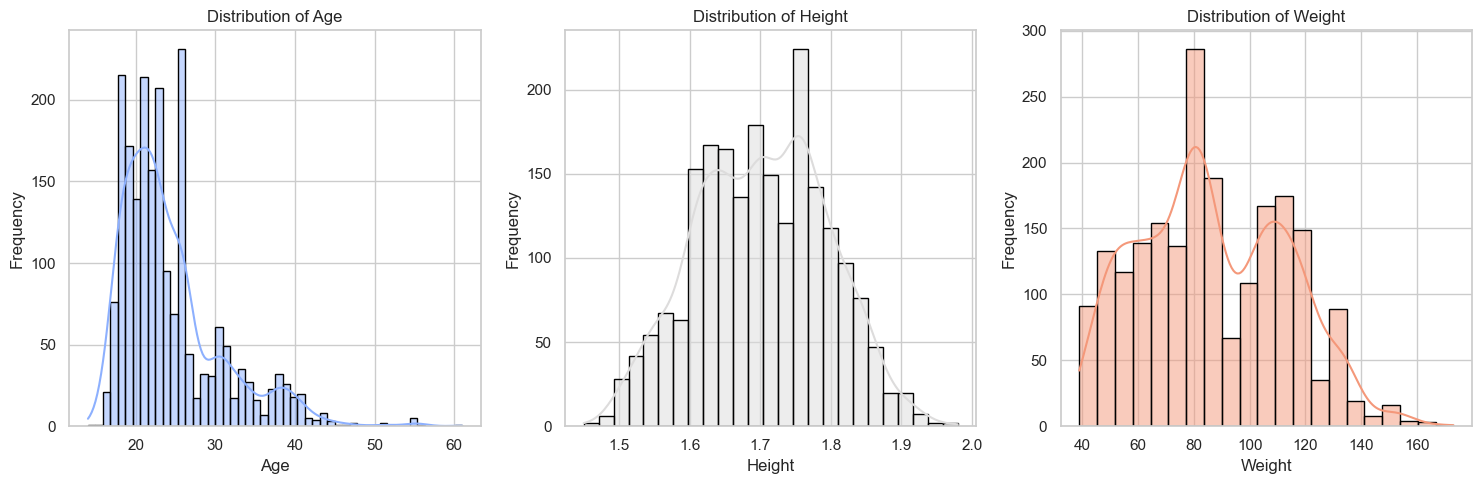

In [14]:
# Select only continuous numerical features
num_cols = ["Age", "Height", "Weight"]

# Set a Seaborn style for better visuals
sns.set(style="whitegrid")

# Set figure size
plt.figure(figsize=(15, 5))

# Loop through each numerical column and plot its distribution
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)  # 1 row, 3 columns layout
    
    # Rich color histogram + KDE curve
    sns.histplot(
        obesity_df[col],
        kde=True,
        color=sns.color_palette("coolwarm", 3)[i-1],
        edgecolor="black",
        linewidth=1
    )
    
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")

# Adjust layout
plt.tight_layout()

plt.show()


 ###  Distribution Plot: Key Numeric Insights

**1. Age Distribution**

- Strongly concentrated between **18–30 years**, confirming a young population.

- Noticeable right skew, caused by fewer older individuals (up to 60 years).

- No abnormal age values—distribution looks realistic.

**2. Height Distribution**

- Appears roughly normal (bell-shaped), centered around 1.7 m.

- Slight spread from 1.45 m to 1.98 m, all within typical adult human height range.

- No extreme outliers visible.

**3. Weight Distribution**

- Shows higher variability with weights ranging from **39 to ~170 kg**.

- Clear right-skew due to heavier participants—expected for an obesity-focused dataset.

- Distribution suggests presence of normal weight, overweight, and obese groups.


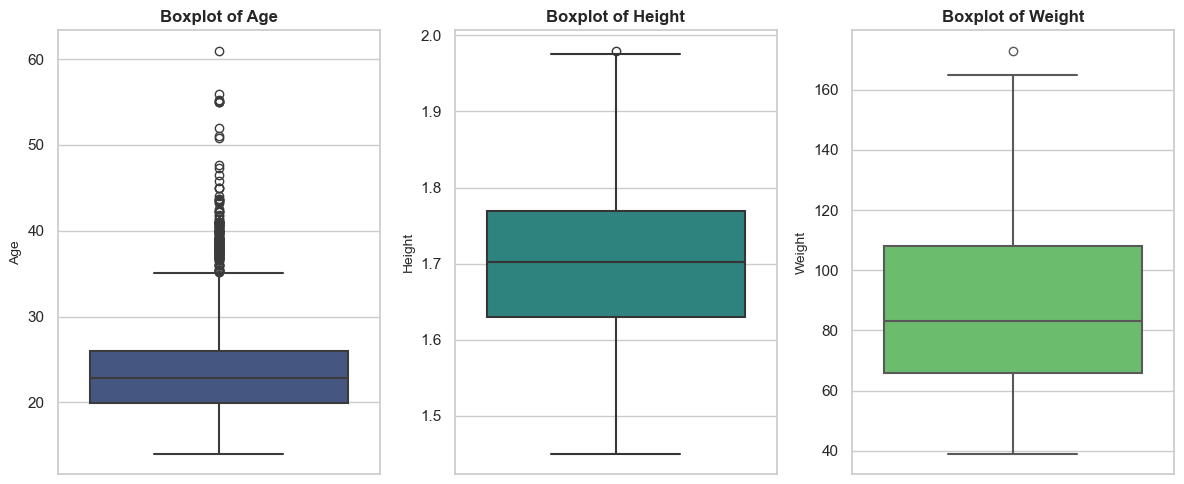

In [15]:
# Continuous numerical features only
num_cols = ["Age", "Height", "Weight"]

# Seaborn style for clean visuals
sns.set(style="whitegrid")

# Set figure size
plt.figure(figsize=(12, 5))

# Loop through numerical variables and create boxplots
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)  # 1 row, 3 columns
    
    sns.boxplot(
        y=obesity_df[col],
        color=sns.color_palette("viridis", 3)[i-1],
        linewidth=1.5
    )
    
    plt.title(f"Boxplot of {col}", fontsize=12, fontweight='bold')
    plt.ylabel(col, fontsize=10)

# Adjust layout
plt.tight_layout()

plt.show()


 ### Boxplots: Key Numeric Insights

The boxplots show that Age is concentrated around young adults, with a median near 23 years and several higher-age outliers extending up to 60, indicating a right-skewed distribution but no unrealistic values. Height displays a relatively symmetric spread centered around 1.70 m, with only a few natural outliers at the shorter and taller extremes, all within normal biological ranges. Weight exhibits the largest variability, with a median around 83–85 kg and a clear right skew driven by higher-weight individuals, including outliers above 160 kg that reflect the obese portion of the population, which is expected in an obesity-focused dataset.

 ### Outlier Detection and Capping Using the IQR Method

We apply IQR-based outlier capping to prevent extreme numerical values (Age, Height, Weight) from disproportionately influencing model training. While the dataset contains no impossible values, these high-end outliers can distort scaling, widen feature ranges, and negatively impact distance-based or tree-based models. Capping them ensures more stable model behavior while preserving the overall distribution of the data.

In [16]:
for col in num_cols:
    Q1 = obesity_df[col].quantile(0.25)
    Q3 = obesity_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    obesity_df[col] = np.where(obesity_df[col] < lower_bound, lower_bound,
                               np.where(obesity_df[col] > upper_bound, upper_bound, obesity_df[col]))

 ## Boxplot: After Outlier Treatment

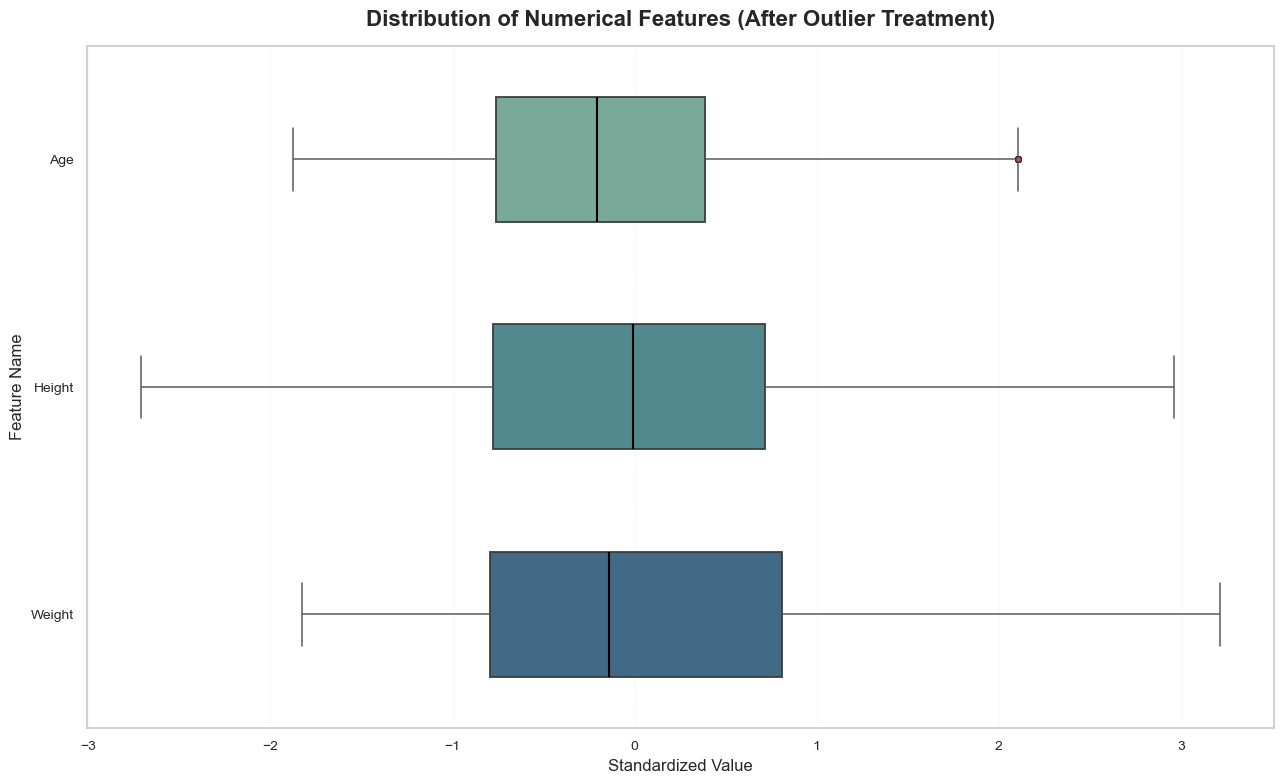

In [17]:
# Normalize only for plotting (DO NOT overwrite original data)
scaled_df = obesity_df[num_cols].apply(lambda x: (x - x.mean()) / x.std())

plt.figure(figsize=(13, 8))

# Elegant palette
palette = sns.color_palette("crest", n_colors=len(num_cols))

sns.boxplot(
    data=scaled_df,
    orient='h',
    palette=palette,
    linewidth=1.4,
    width=0.55,
    boxprops=dict(alpha=0.9, edgecolor='#3A3A3A'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='#5A5A5A', linewidth=1.1),
    capprops=dict(color='#5A5A5A', linewidth=1.1),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='#D64550', alpha=0.4)
)

plt.title(
    "Distribution of Numerical Features (After Outlier Treatment)",
    fontsize=16, fontweight='bold', pad=14
)

plt.xlabel("Standardized Value", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Soft minimal grid
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.28)

plt.tight_layout()
plt.show()


The absence of extreme points confirms that the IQR capping was successfully applied. The shorter whiskers indicate a tighter and more consistent data range, while the overall data structure remains preserved, ensuring no significant information loss.

## Correlation Analysis

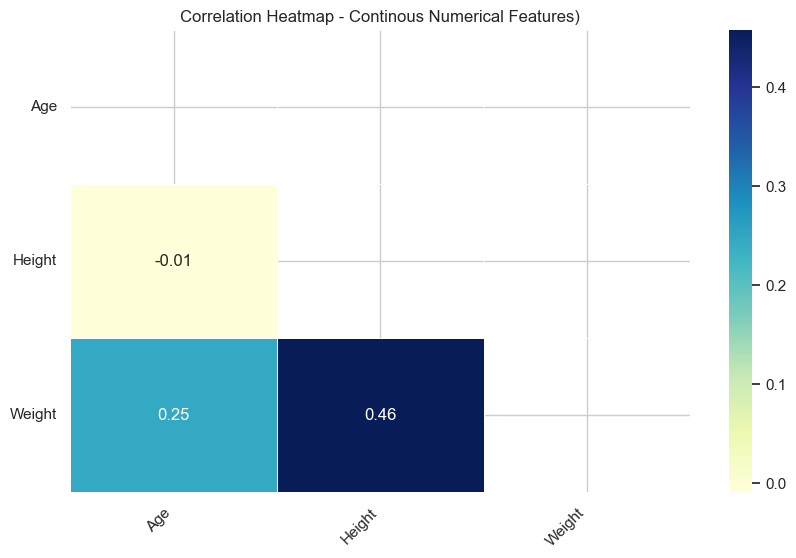

In [18]:
# Correlation Heatmap (Numerical Columns Only)

# Set figure size for better readability
plt.figure(figsize=(10, 6))

# Create a boolean mask to hide the upper triangle of the correlation matrix
# This avoids redundancy since correlation matrices are symmetric
mask = np.triu(np.ones_like(obesity_df[num_cols].corr(), dtype=bool))

# Generate the heatmap showing correlations among numerical features
sns.heatmap(
    obesity_df[num_cols].corr(),  # Compute correlation matrix for numeric columns
    mask=mask,                    # Apply mask to hide upper triangle
    annot=True,                   # Display correlation coefficients inside cells
    cmap='YlGnBu',                # Use yellow-green-blue color palette
    fmt=".2f",                    # Format correlation values to 2 decimal places
    linewidths=0.5                # Add thin lines between cells for clarity
)

# Rotate axis labels for better visibility
plt.xticks(rotation=45, ha='right')   # Tilt x-axis labels to 45° (readable)
plt.yticks(rotation=0)                # Keep y-axis labels horizontal

# Add an informative title
plt.title("Correlation Heatmap - Continous Numerical Features)")

# Display the heatmap
plt.show()

 ### Key Insights from Correlation Heatmap

- Weight and Height show a moderate positive correlation (0.46) — taller individuals tend to weigh more.

- Age and Weight have a weak positive correlation (0.25) — slightly higher weights in older participants.

- Age and Height show almost no correlation (−0.01) — height is not influenced by age within this adult-heavy dataset.


## Categorical Feature Insights

In [19]:
# ---------------------------------------------------------
# CATEGORICAL FEATURES (Nominal Variables)
# ---------------------------------------------------------
# These are non-ordered categories. OneHotEncoding will be used.
categorical_cols = [
    "Gender",                          # Male / Female
    "family_history_with_overweight",  # yes / no
    "HighCal_Food_Consumption",        # yes / no
    "Snacking_Habits",                 # Sometimes / Frequently / Always / no
    "Smoking_Habit",                   # yes / no
    "Calorie_Monitoring",              # yes / no
    "Alcohol_Consumption",             # no / Sometimes / Frequently / Always
    "Transport_Mode"                   # Public transport / Automobile / Bike / etc.
]

# ---------------------------------------------------------
# TARGET VARIABLE (Separate from predictors)
# ---------------------------------------------------------
# DO NOT include the target inside categorical_cols
target = "Obesity_Level"              
# Multi-class labels (Insufficient, Normal, Overweight I, II, Obesity I, II, III)

# ---------------------------------------------------------
# ORDINAL FEATURES (Ordered Categorical Variables)
# ---------------------------------------------------------
# These categories have a natural order. No OneHotEncoding.
ordinal_cols = [
    "Veg_Consumption_Freq",    # 1 = Rarely, 2 = Sometimes, 3 = Often
    "Num_Main_Meals",          # 1–4 meals per day (ordered)
    "Water_Intake",            # 1–3 (low → high)
    "Physical_Activity_Freq",  # 0–3 (sedentary → active)
    "Tech_Usage_Time"          # 0–2 (low → high device usage)
]

 ### 1. Binary Categorical Variables (4 variables)

- Gender
- family_history_with_overweight
- Smoking_Habit
- Calorie_Monitoring

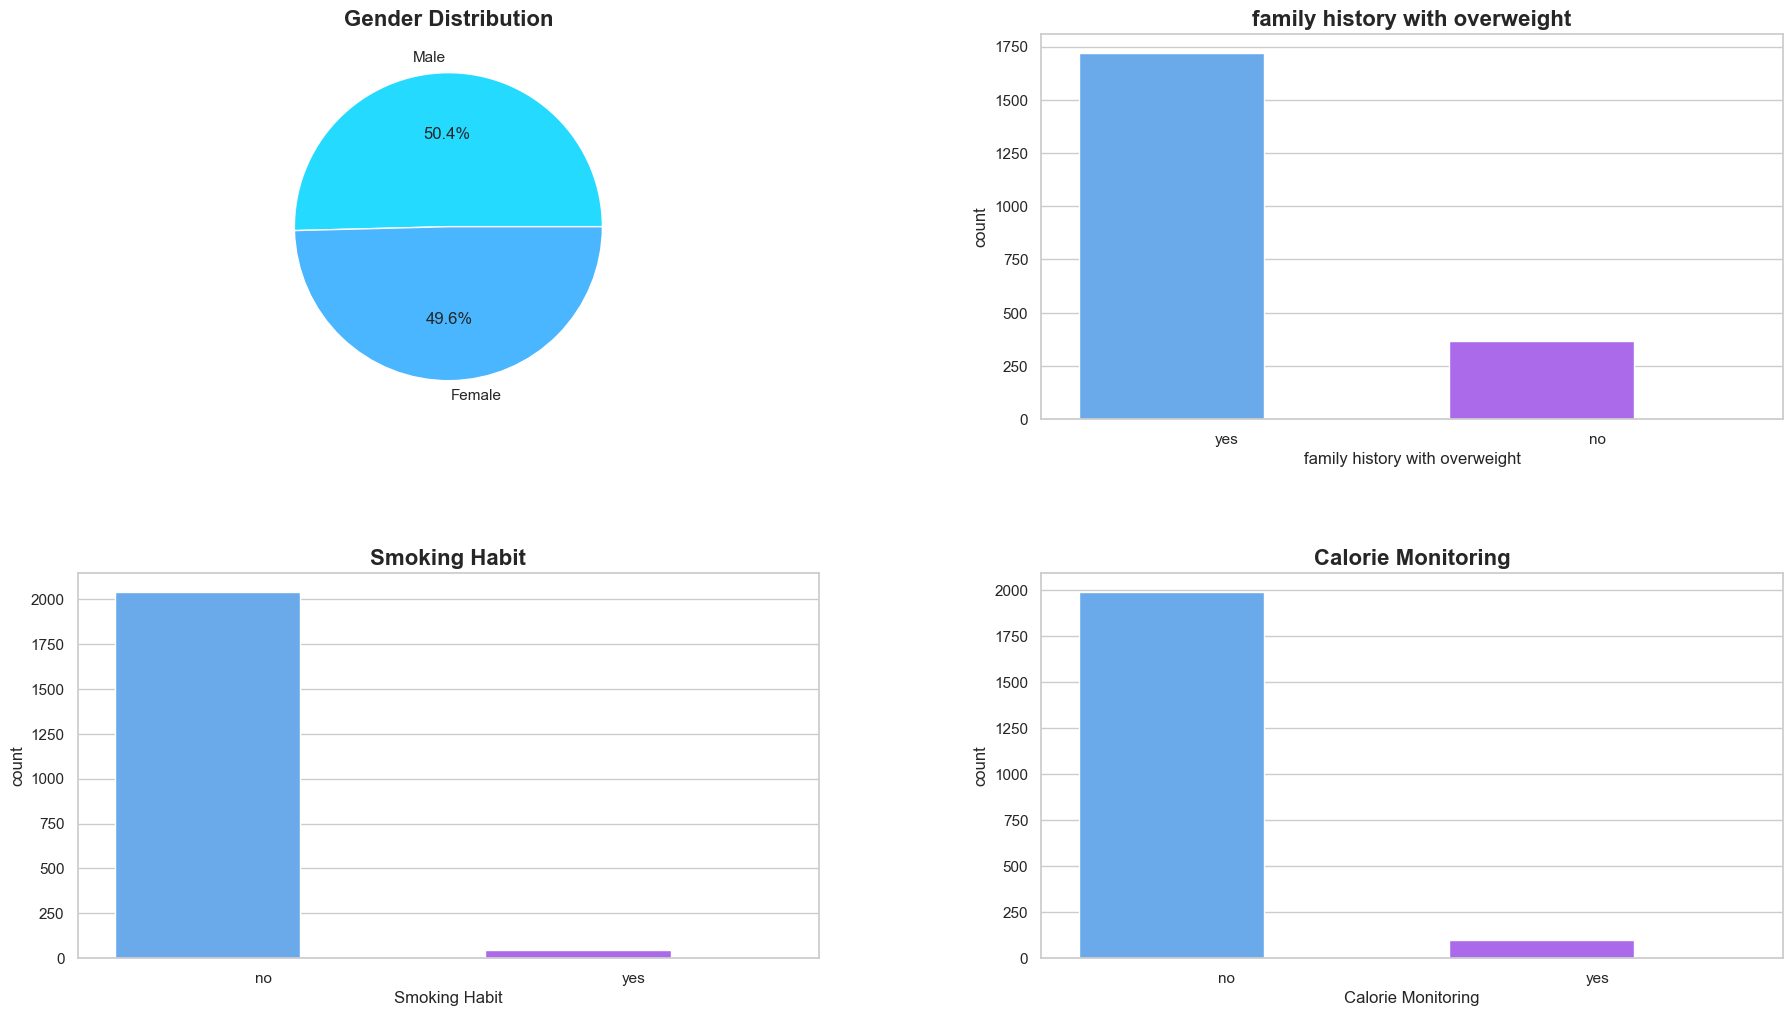

In [20]:
sns.set(style="whitegrid", palette="pastel")

# Binary columns with raw 0/1 values
binary_cols = [
    "Gender",
    "family_history_with_overweight",
    "Smoking_Habit",
    "Calorie_Monitoring"
]

plt.figure(figsize=(22, 12))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 2, i)

    # Pie chart ONLY for Gender
    if col == "Gender":
        counts = obesity_df[col].value_counts()
        plt.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            colors=sns.color_palette("cool"),
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        plt.title("Gender Distribution", fontsize=16, fontweight="bold")

    # Countplots for other binary variables
    else:
        ax = sns.countplot(data=obesity_df, x=col, palette="cool")

        # Narrow bars
        for patch in ax.patches:
            patch.set_width(0.5)

        plt.title(col.replace("_", " "), fontsize=16, fontweight="bold")
        plt.xlabel(col.replace("_", " "), fontsize=12)
        plt.xticks(rotation=0)

# Add spacing between plots
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.show()


 ### 2. Small Multi-Class Categorical Variables 

- HighCal_Food_Consumption
- Snacking_Habits
- Alcohol_Consumption

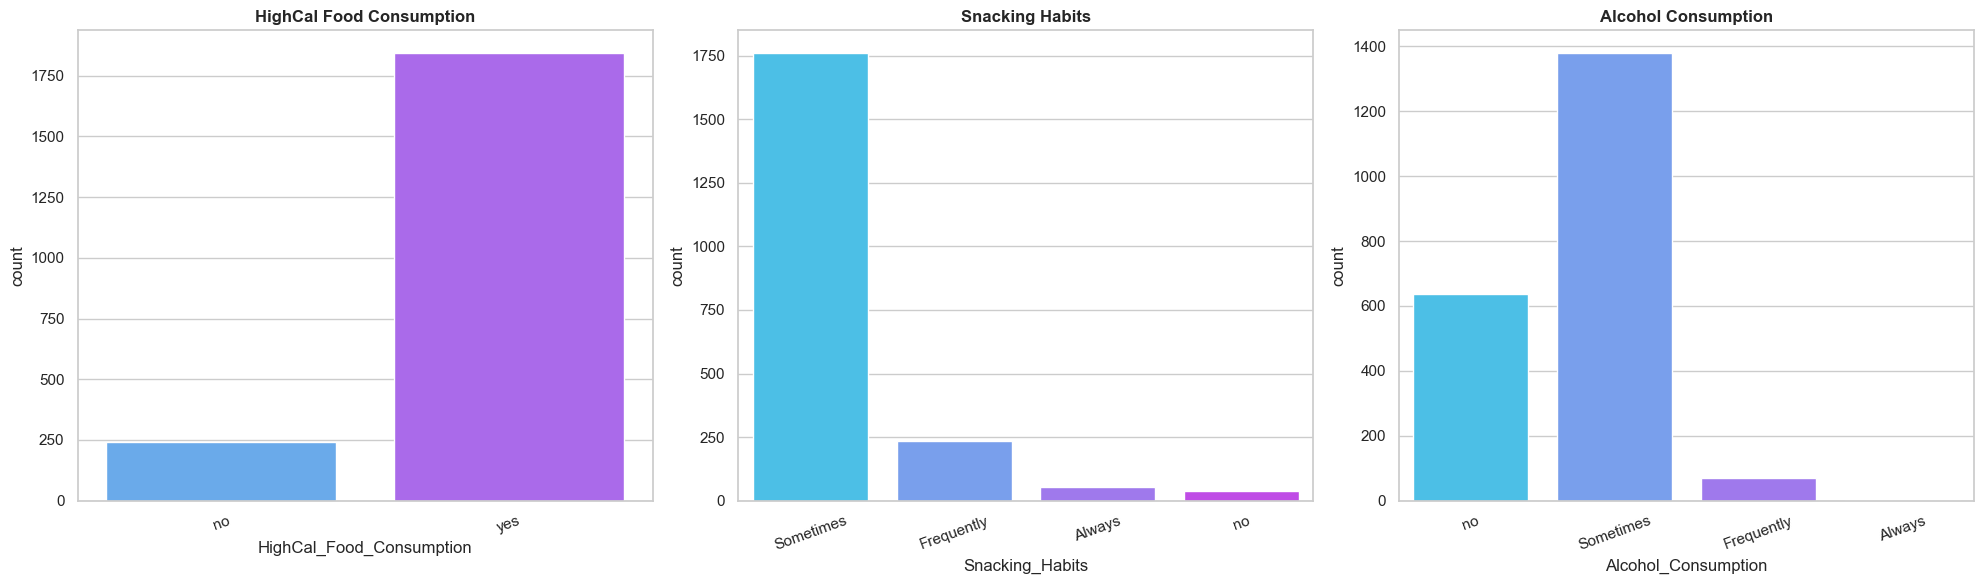

In [21]:
# Set plot style
sns.set(style="whitegrid", palette="pastel")

# Multi-class categorical variables
multi_class_cols = [
    "HighCal_Food_Consumption",
    "Snacking_Habits",
    "Alcohol_Consumption"
]

plt.figure(figsize=(20, 6))

# Plot each variable
for i, col in enumerate(multi_class_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=obesity_df, x=col, palette="cool")
    plt.title(col.replace("_", " "), fontweight="bold")
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


 ### 3. Horizontal Countplots (2 variables)

Transport_Mode, Obesity_Level

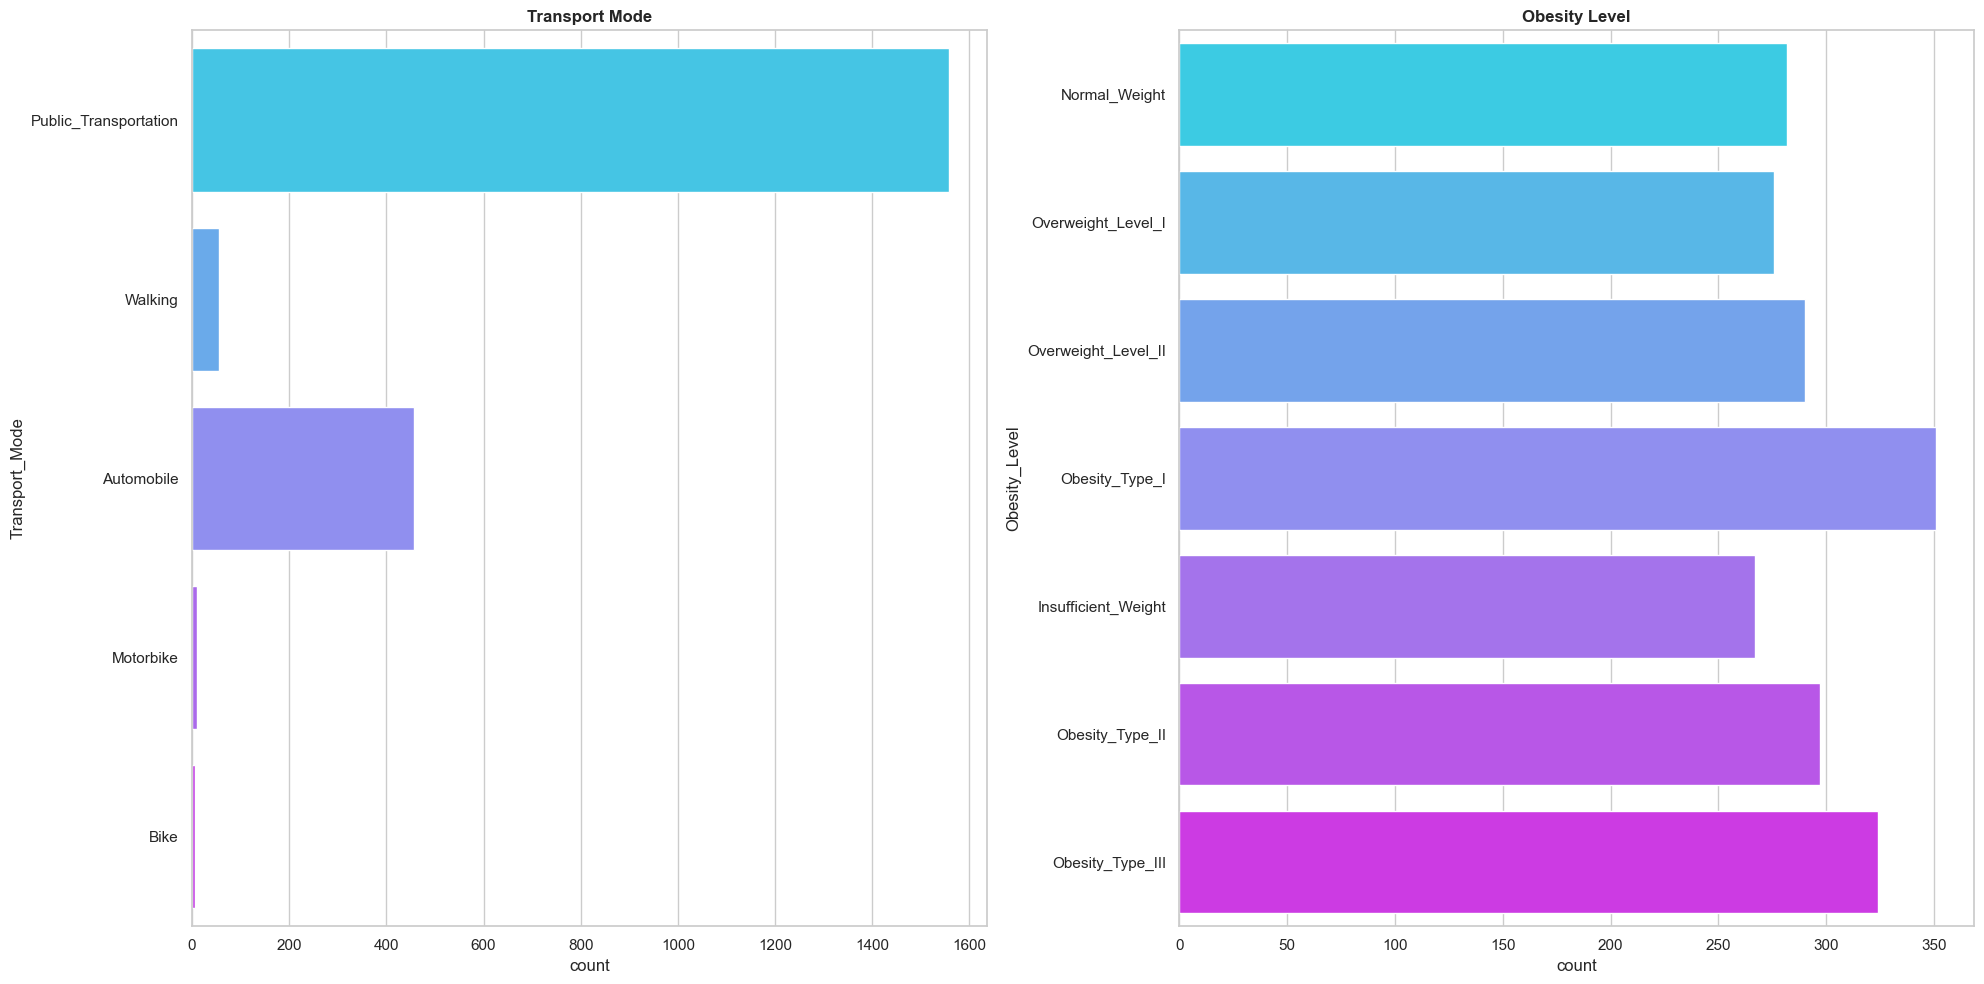

In [22]:
# Set plot style
sns.set(style="whitegrid", palette="pastel")

# Categorical features better shown horizontally
horizontal_cols = [
    "Transport_Mode",
    "Obesity_Level"
]

plt.figure(figsize=(20, 10))

# Plot each variable as a horizontal countplot
for i, col in enumerate(horizontal_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=obesity_df, y=col, palette="cool")
    plt.title(col.replace("_", " "), fontweight="bold")

plt.tight_layout()
plt.show()


 ### 4. Ordinal Categorical Variables (5 variables)

- Veg_Consumption_Freq
- Num_Main_Meals
- Water_Intake
- Physical_Activity_Freq
- Tech_Usage_Time

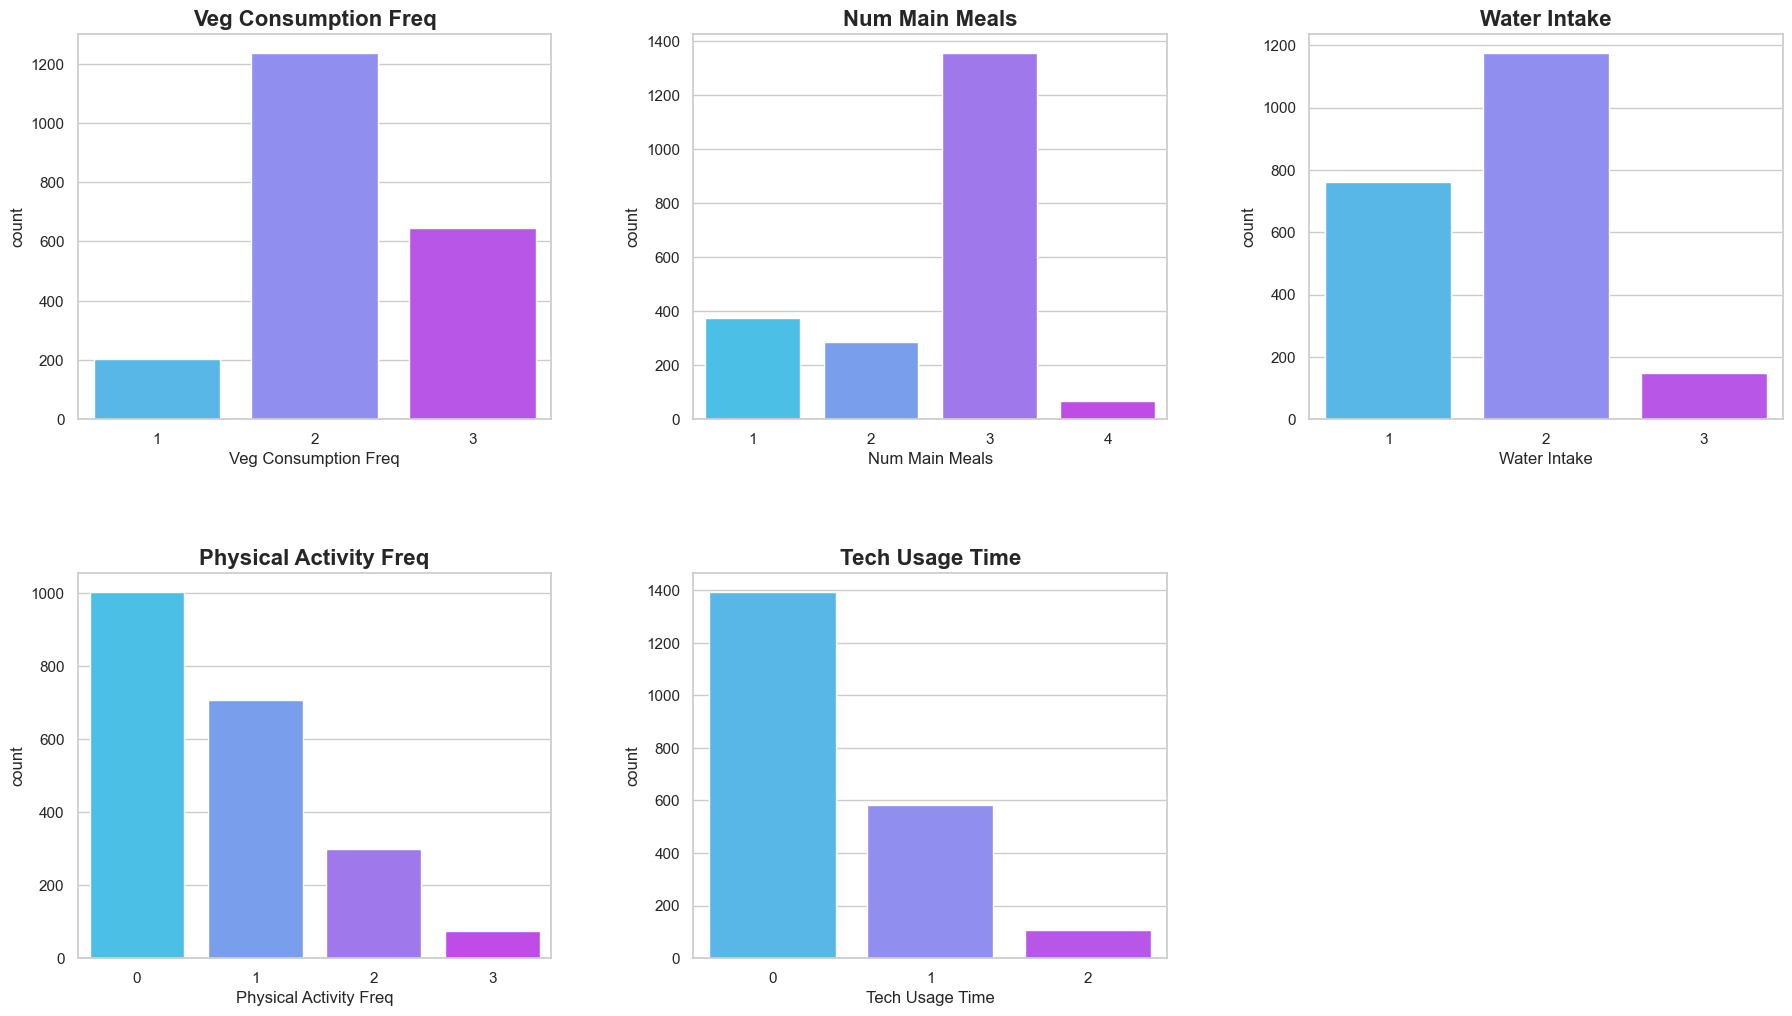

In [23]:
# Ordinal features (ordered categories)
ordinal_cols = [
    "Veg_Consumption_Freq",
    "Num_Main_Meals",
    "Water_Intake",
    "Physical_Activity_Freq",
    "Tech_Usage_Time"
]

# Ensure ordinal columns are integers
obesity_df[ordinal_cols] = obesity_df[ordinal_cols].astype(int)

sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(22, 12))

# Plot each ordinal variable in order
for i, col in enumerate(ordinal_cols, 1):
    plt.subplot(2, 3, i)
    unique_vals = sorted(obesity_df[col].unique())

    sns.countplot(
        data=obesity_df,
        x=col,
        order=unique_vals,
        palette="cool"
    )

    plt.title(col.replace("_", " "), fontsize=16, fontweight="bold")
    plt.xlabel(col.replace("_", " "), fontsize=12)
    plt.xticks(rotation=0)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


 ### Key Insights from Categorical Feature Analysis
**Lifestyle & Eating Habits**

    - HighCal Food: Large majority frequently consume high-calorie foods.
    
    - Snacking Habits: “Sometimes” is dominant; very few avoid snacking.
    
    - Alcohol Consumption: Mostly “Sometimes”; heavy drinking is rare.
    
    - Calorie Monitoring: Very few track calories → low awareness of intake.

**Physical Activity & Tech Usage**
    
    - Physical Activity: Most participants do little to no exercise.
    
    - Tech Usage: Majority spend long hours (low physical mobility), supporting a sedentary lifestyle.

**Family & Personal Habits**

    - Family history of overweight: Strongly skewed toward "Yes".
    
    - Smoking: Very few smokers → smoking has limited representation.

**Transport**

    - Public transportation is overwhelmingly the most common mode; walking/cycling extremely low → reflects low daily physical activity.

**Obesity Levels**

    - Distribution is balanced across all obesity categories, with no extreme class imbalance; good for modeling.

**Ordinal Dietary Features**
    
    - Veg Intake: Mostly moderate (level 2).
    
    - Number of Meals: “3 meals/day” is dominant.
    
    - Water Intake: Mostly moderate (level 2).

## Target Variable Analysis: BMI and Demographic Features

 ### Gender vs Obesity Category

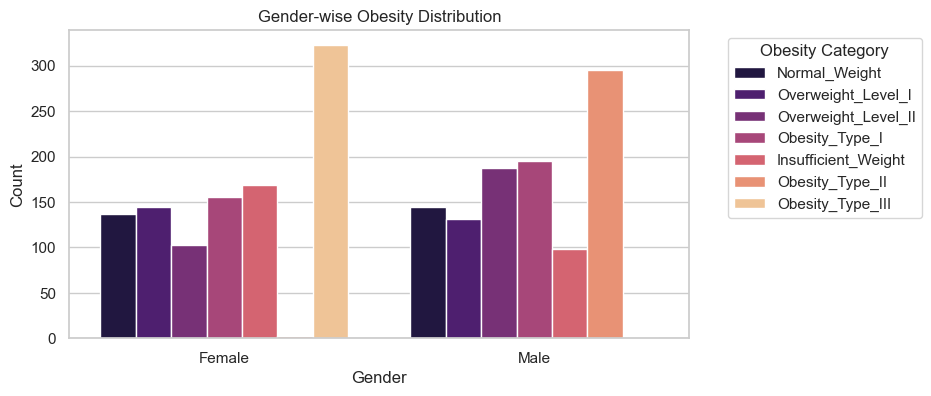

In [24]:

# Set the figure size for better visibility
plt.figure(figsize=(8, 4))

# Create a count plot to compare obesity levels across gender
sns.countplot(
    x='Gender',                     # Gender on the x-axis
    hue='Obesity_Level',            # Different obesity categories represented by colors
    data=obesity_df,                # Dataset used for visualization
    palette='magma'                 # Choose an appealing color palette
)

# Add plot title and axis labels
plt.title("Gender-wise Obesity Distribution")   # Title of the plot
plt.xlabel("Gender")                            # Label for x-axis
plt.ylabel("Count")                             # Label for y-axis

# Place legend outside the plot for clarity
plt.legend(
    title='Obesity Category',                   # Legend title
    bbox_to_anchor=(1.05, 1),                   # Position legend slightly outside the plot
    loc='upper left'                            # Anchor point of the legend
)

# Display the final plot
plt.show()

 ### Summary

- Both males and females are represented across all obesity categories, showing that obesity is not restricted to one gender. 
- Males exhibit noticeably higher counts in the severe obesity groups (Obesity_Type_II and Obesity_Type_III), while females show a more balanced spread, with stronger representation in Normal Weight, Overweight_Level_I, and Obesity_Type_I. 
- Insufficient Weight appears infrequently for both genders, indicating that most individuals fall within normal, overweight, or obese categories.


 ### Age, Weight vs Obesity Category

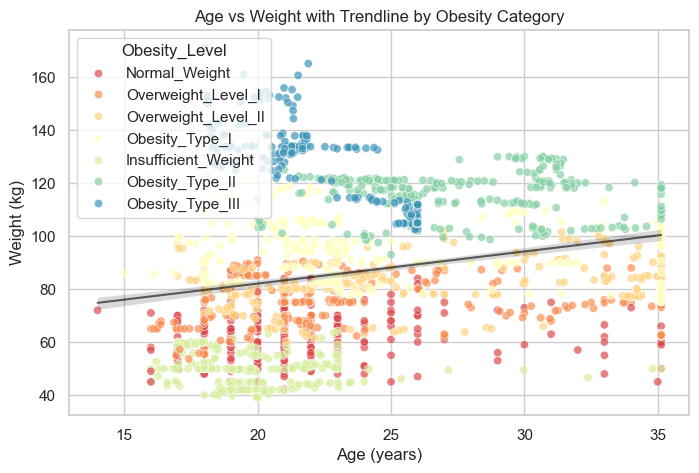

In [39]:
# Relationship between Age and Weight by Obesity Category

plt.figure(figsize=(8, 5))

# Scatter plot
sns.scatterplot(
    x='Age',
    y='Weight',
    hue='Obesity_Level',
    data=obesity_df,
    palette='Spectral',
    alpha=0.7
)

# Regression (trend) line
sns.regplot(
    x='Age',
    y='Weight',
    data=obesity_df,
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.5, 'alpha': 0.6}
)

plt.title("Age vs Weight with Trendline by Obesity Category")
plt.xlabel("Age (years)")
plt.ylabel("Weight (kg)")

plt.show()


 ### Summary
The scatterplot shows a weak positive relationship between age and weight, indicating that weight tends to increase slightly as age increases. Obesity categories form distinct clusters—higher obesity levels consistently appear at higher weight ranges regardless of age. This separation suggests that weight is a stronger discriminator for obesity classification than age.

# Data Prepartion for Classification

 ### Identify Columns Groups

In [25]:
categorical_cols = [
    "Gender",
    "family_history_with_overweight",
    "HighCal_Food_Consumption",
    "Snacking_Habits",
    "Smoking_Habit",
    "Calorie_Monitoring",
    "Alcohol_Consumption",
    "Transport_Mode"
]

ordinal_cols = [
    "Veg_Consumption_Freq",   
    "Num_Main_Meals",        
    "Water_Intake",          
    "Physical_Activity_Freq",
    "Tech_Usage_Time"
]

numerical_cols = ["Age", "Height", "Weight"]

target = "Obesity_Level"

### Create Preprocessing Pipeline

- Categorical: One-hot encode
- Ordinal: No encoding needed (already numeric)
- Numerical: StandardScaler

In [26]:
# ColumnTransformer to apply different preprocessing to each feature type
preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_cols),  # Encode categorical variables
    ("scale", StandardScaler(), numerical_cols),                          # Scale numerical features
    ("ordinal_pass", "passthrough", ordinal_cols)                         # Keep ordinal features as-is
])


### Split the Data

In [27]:
# Separate features and target
X = obesity_df.drop(columns=[target])
y = obesity_df[target]

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Classification Model Training

## Random Forest Classifier

Random Forest is chosen because it handles mixed data types, captures nonlinear relationships, and is robust to outliers and noise, making it well-suited for lifestyle and obesity data. It offers strong accuracy with minimal tuning and provides feature importance, which helps identify key factors influencing obesity. Its stability and interpretability make it an ideal model for this classification task.

In [28]:
# Random Forest pipeline with preprocessing
rf_pipe = Pipeline([
    ("preprocess", preprocessor),                         # Apply encoding/scaling
    ("model", RandomForestClassifier(random_state=42))    # Classification model
])


 ### Random Forest Hyperparameter Tuning

In [29]:
# Random Forest hyperparameter search space
rf_params = {
    "model__n_estimators": [200, 300, 500, 700],   # number of trees
    "model__max_depth": [10, 20, 30, 40, None],    # tree depth
    "model__min_samples_split": [2, 5, 10],        # split threshold
    "model__min_samples_leaf": [1, 2, 4],          # minimum leaf size
    "model__bootstrap": [True, False]              # sampling method
}

# Randomized search for best parameters
rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the model on training data
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best Random Forest Parameters:", rf_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest Parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 40, 'model__bootstrap': False}


## Logistic Regression

Logistic Regression is used as a baseline model because it is simple, fast, and highly interpretable. It helps establish a clear performance benchmark before evaluating more complex models. LR works well when relationships between features and the target are linear or moderately nonlinear, and it provides transparent coefficients that reveal how lifestyle factors influence obesity levels. Its efficiency and clarity make it an essential comparison model in this classification task.

In [30]:
# Logistic Regression pipeline with preprocessing
logreg_pipe = Pipeline([
    ("preprocess", preprocessor),                 # Apply encoding/scaling
    ("model", LogisticRegression(max_iter=2000))  # Logistic Regression classifier
])


 ### Logistic Regression Hyperparameter Tuning

In [31]:
# Hyperparameter search space for Logistic Regression
logreg_params = {
    "model__C": [0.01, 0.1, 1, 5, 10, 20],     # Regularization strength
    "model__solver": ["lbfgs", "liblinear"]    # Optimization algorithms
}

# Randomized search for best LR parameters
logreg_search = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=logreg_params,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit model on training data
logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_

print("Best Logistic Regression Params:", logreg_search.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Logistic Regression Params: {'model__solver': 'lbfgs', 'model__C': 20}


# Model Evaulation

### Model Evaluation: Accuracy & Classification Report

In [32]:
# Function to evaluate any classification model
def evaluate_model(model, name):
    print(f"\n{name}")
    print("-" * 60)

    # Predictions on train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Accuracy scores
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

    # Detailed performance report
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))


In [33]:
# Evaluate tuned Random Forest and Logistic Regression models
evaluate_model(best_rf, "Random Forest (Tuned)")
evaluate_model(best_logreg, "Logistic Regression (Tuned)")



Random Forest (Tuned)
------------------------------------------------------------
Train Accuracy: 1.0
Test Accuracy : 0.916267942583732

Classification Report (Test Data):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.74      0.86      0.80        57
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.85      0.80      0.82        55
Overweight_Level_II       0.86      0.86      0.86        58

           accuracy                           0.92       418
          macro avg       0.92      0.91      0.91       418
       weighted avg       0.92      0.92      0.92       418


Logistic Regression (Tuned)
------------------------------------------------------------
Train Accuracy: 0.9730377471539844
Test Accuracy : 0.952153110

In [34]:
# Create a comparison table for model performance
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    
    # Training accuracy for each model
    "Train Accuracy": [
        accuracy_score(y_train, best_rf.predict(X_train)),
        accuracy_score(y_train, best_logreg.predict(X_train)),
    ],
    
    # Test accuracy for each model
    "Test Accuracy": [
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_logreg.predict(X_test)),
    ]
})

comparison_df


,Model,Train Accuracy,Test Accuracy
0,Random Forest,1.000000,0.916268
1,Logistic Regression,0.973038,0.952153


### Confusion Matrix Visualization Function

In [35]:
# Plot confusion matrix for a classification model
def plot_cm(model, name):
    y_pred = model.predict(X_test)
    labels = sorted(y.unique())  # Sorted class labels

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    # Plot heatmap
    plt.figure(figsize=(9, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


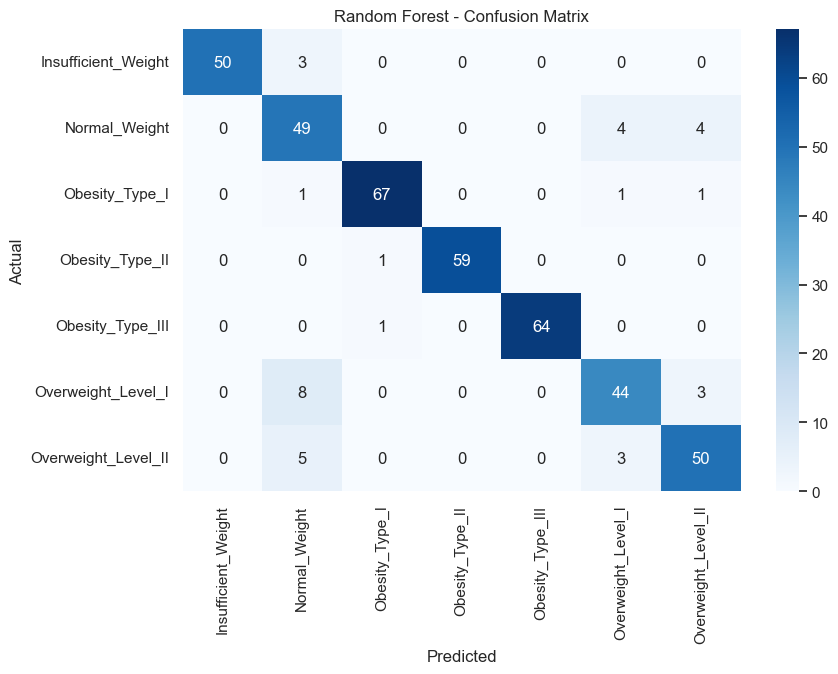

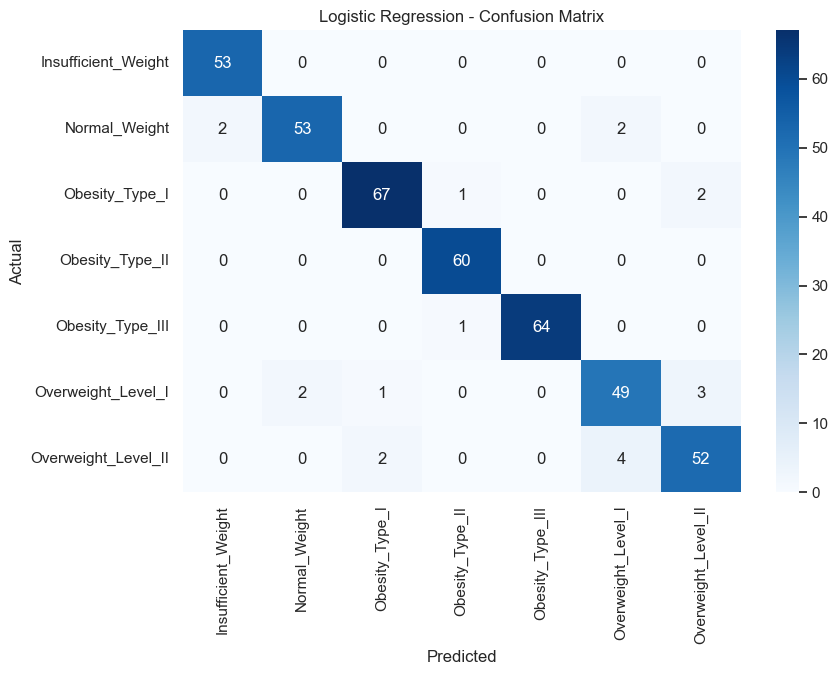

In [36]:
# Plot confusion matrices for both tuned models
plot_cm(best_rf, "Random Forest")
plot_cm(best_logreg, "Logistic Regression")

## Model Comparision 

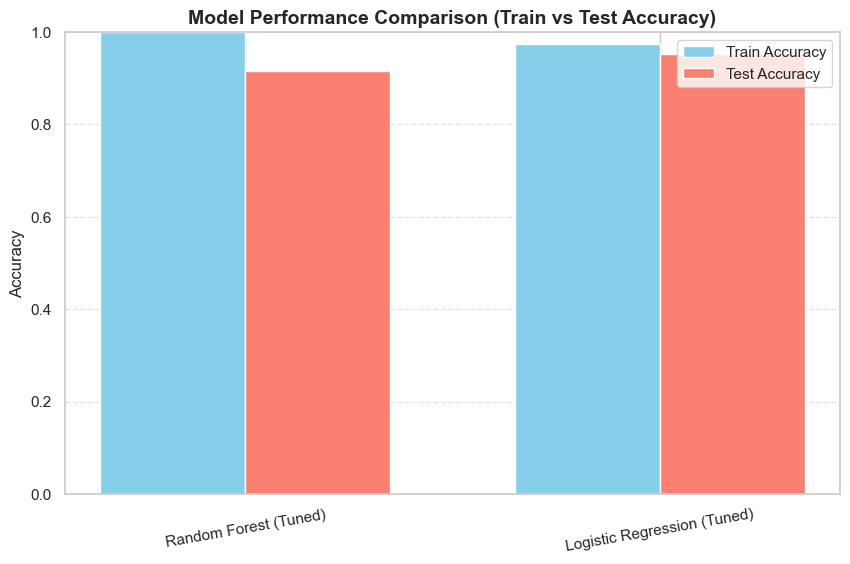

In [37]:
# Extract accuracies
models = ["Random Forest (Tuned)", "Logistic Regression (Tuned)"]

train_scores = [
    accuracy_score(y_train, best_rf.predict(X_train)),
    accuracy_score(y_train, best_logreg.predict(X_train))
]

test_scores = [
    accuracy_score(y_test, best_rf.predict(X_test)),
    accuracy_score(y_test, best_logreg.predict(X_test))
]

# Plotting
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_scores, width, label="Train Accuracy", color="skyblue")
plt.bar(x + width/2, test_scores, width, label="Test Accuracy", color="salmon")

plt.xticks(x, models, rotation=10, fontsize=11)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Performance Comparison (Train vs Test Accuracy)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


| **Metric**                  | **Random Forest (Tuned)**       | **Logistic Regression (Tuned)**                  |
| --------------------------- | ------------------------------- | ------------------------------------------------ |
| **Train Accuracy**          | **1.00**                        | **0.973**                                        |
| **Test Accuracy**           | **0.916**                       | **0.952**                                        |
| **Macro Avg Precision**     | 0.92                            | **0.95**                                         |
| **Macro Avg Recall**        | 0.91                            | **0.95**                                         |
| **Macro Avg F1-Score**      | 0.91                            | **0.95**                                         |
| **Performance Consistency** | Moderate (varies by class)      | **High** (balanced across all)                   |
| **Overfitting Risk**        | **High** (train = 1.0)          | Low–Moderate                                     |
| **Best Strengths**          | Complex patterns, obesity types | Overall classification, stable across categories |
| **Weaknesses**              | Weaker on Normal Weight class   | Slightly lower training accuracy                 |


# Critical Evaluation of the Classification Output & Business Impact

The machine learning models used in this project—Random Forest and Logistic Regression—are able to classify individuals into seven different obesity categories with strong accuracy, achieving between 92% and 95% on test data. Logistic Regression performs slightly better on unseen data, suggesting that it generalizes well beyond the training set. This means the models are reliable tools for identifying individuals who may be at risk of becoming overweight or obese, based on a combination of lifestyle habits, demographic information, and behavioral patterns.

From a business or organizational perspective—whether for healthcare providers, fitness companies, nutrition and wellness services, mobile health apps, or insurance firms—these predictions offer meaningful value. Accurate obesity classification allows organizations to deliver more personalized guidance, design targeted interventions, reduce health-related risks, and allocate resources more effectively. In practical terms, this means better prevention strategies, more tailored wellness programs, and improved support for individuals working toward healthier lifestyles.

# How These Insights Benefit Decision-Making

**1. Personalized Health Interventions**

- High precision and recall for categories such as Obesity Type I–III allow organizations to:

- Recommend targeted diet plans or fitness programs.

- Prioritize high-risk individuals for counseling or medical evaluation.

- Design customized mobile app notifications or lifestyle recommendations.

**2. Early Prevention for At-Risk Groups**

- Strong model performance on Overweight and Obesity Type I classes allows:

- Early detection of individuals progressing from overweight to obesity.

- Preventative interventions (nutrition guidance, physical activity nudges, etc.).

**3. Better Resource Allocation**

- Accurate predictions help institutions:

- Focus specialists, dieticians, and trainers on groups most in need.

- Optimize program budgets (e.g., obesity prevention programs vs. treatment plans).

- Plan inventory for wellness products or coaching sessions.

**4. Improved Customer Segmentation**

- Understanding obesity levels allows businesses to:

- Offer tiered services (basic → intense programs).

- Build user personas for marketing campaigns.

- Provide personalized pricing or subscription plans.

**5. Support for Policy & Strategic Decisions**

- Public health organizations can use aggregated results to:

- Identify patterns such as high tech-use time, low activity levels, or high-calorie food consumption.

- Build targeted awareness programs (e.g., youth sedentary lifestyle campaigns).

- Monitor population trends and adjust policies.

# Actionable Recommendations

1.	Personalised Wellness Plans: Use model predictions to create tailored exercise routines, meal plans, and health goals, improving user engagement and program adherence.
2.	Risk-Flagging System: Automatically identify high-, medium-, and low-risk individuals, helping healthcare teams prioritise support and allocate resources effectively.
3.	Behavioural Nudges: Send small, timely reminders such as increasing water intake or taking short walks to promote consistent, healthier habits.
4.	Targeted Education Programs: Develop focused workshops and educational content based on common risk behaviours identified in the dataset.
5.	Continuous Monitoring & Retraining: Update the model regularly, add new features (e.g., sleep, stress), and refine insights to keep predictions accurate and actionable over time.


# Conclusion

The classification models provide strong predictive power and can significantly enhance decision-making. Organizations can use the insights to deliver more personalized, efficient, and impactful health interventions, ultimately improving user outcomes and reducing costs. The actionable recommendations provided support both operational efficiency and strategic planning, making the models highly practical for real-world deployment.